# Processamento de dados

## 1 - Mapeamento
    1.1 - Criar um dicionario para mapear cada CID unico
    1.2 - Criar um dicionario para mapear cada efeito colateral unico
    1.3 - Criar um dicionario para a traducao do codigo do efeito colateral para seu nome

## 2 - Substituição
    2.1 - Criar um df_completo para poder alterar pelos valores do dicionario
    2.2 - Alterar os valores para os mapeados (cid de 0 a 644 e efeitos de 0 a 1316)

## 3 - Visualização
    3.1 - Visualização do grafo a partir da biblioteca NetworkX

## 4 - Geração das Features
    4.1 - Obter a representação SMILES (texto químico) para cada um dos 645 CIDs únicos via PubChem 
    4.2 - Utilizar o RDKit para converter cada SMILES em um Morgan Fingerprint (vetor binário de 1024 bits)
    4.3 - Construir a Matriz de Nós X: um tensor de tamanho [645, 1024] onde a linha i contém o fingerprint da droga mapeada com o ID i.

## 5 - Criando o Objeto Data
    5.1 Criar o data.x
    5.2 Criar edge_index
    5.3 Criar edge_type

## 6 - Separar as conexões para Treino, Validação e Teste

In [1]:
!pip install torch torch-geometric rdkit pubchempy pandas numpy

In [2]:
import pandas as pd
import numpy as np
import torch
from rdkit import Chem
from rdkit.Chem import AllChem
import pubchempy as pcp

In [3]:
df = pd.read_csv("ChChSe-Decagon_polypharmacy.csv")

In [4]:
df.head(8)

,# STITCH 1,STITCH 2,Polypharmacy Side Effect,Side Effect Name
0,CID000002173,CID000003345,C0151714,hypermagnesemia
1,CID000002173,CID000003345,C0035344,retinopathy of prematurity
2,CID000002173,CID000003345,C0004144,atelectasis
3,CID000002173,CID000003345,C0002063,alkalosis
4,CID000002173,CID000003345,C0004604,Back Ache
5,CID000002173,CID000003345,C0034063,lung edema
6,CID000002173,CID000003345,C0085631,agitated
7,CID000002173,CID000003345,C0013384,abnormal movements


In [5]:
df.dtypes

# STITCH 1                  object
STITCH 2                    object
Polypharmacy Side Effect    object
Side Effect Name            object
dtype: object

In [6]:
drogas_unicas = df[['# STITCH 1', 'STITCH 2']].stack().unique() # utiliza o stack para "colocar a coluna 2 em baixo da 1", tornando-as apenas uma
print(drogas_unicas)

['CID000002173' 'CID000003345' 'CID000005206' 'CID000009433'
 'CID000003929' 'CID000150610' 'CID000001302' 'CID000005064'
 'CID000005267' 'CID000010631' 'CID000004601' 'CID000005376'
 'CID000005090' 'CID000005556' 'CID000004946' 'CID000130881'
 'CID000005391' 'CID000005584' 'CID000002802' 'CID005381226'
 'CID000004212' 'CID000060953' 'CID000000596' 'CID000005726'
 'CID000002522' 'CID000003308' 'CID000003405' 'CID000060795'
 'CID000003446' 'CID004183806' 'CID000004107' 'CID000004917'
 'CID000003161' 'CID000071329' 'CID000003823' 'CID000003911'
 'CID000054454' 'CID000002156' 'CID000004411' 'CID000002907'
 'CID000004192' 'CID000083786' 'CID000003348' 'CID000000838'
 'CID000002617' 'CID000001986' 'CID000006691' 'CID000004920'
 'CID000005478' 'CID006398525' 'CID000003937' 'CID005311048'
 'CID000004158' 'CID000005523' 'CID000003696' 'CID000004112'
 'CID000003899' 'CID000004473' 'CID000000853' 'CID005311181'
 'CID000032797' 'CID000059708' 'CID000003826' 'CID000003143'
 'CID000004736' 'CID0000

In [7]:
quant_drogas_unicas = df[['# STITCH 1', 'STITCH 2']].stack().nunique()
print(quant_drogas_unicas)

645


In [8]:
dict_drogas = {}

for i in range(0, quant_drogas_unicas, 1):
    dict_drogas[drogas_unicas[i]] = i

print(dict_drogas)

{'CID000002173': 0, 'CID000003345': 1, 'CID000005206': 2, 'CID000009433': 3, 'CID000003929': 4, 'CID000150610': 5, 'CID000001302': 6, 'CID000005064': 7, 'CID000005267': 8, 'CID000010631': 9, 'CID000004601': 10, 'CID000005376': 11, 'CID000005090': 12, 'CID000005556': 13, 'CID000004946': 14, 'CID000130881': 15, 'CID000005391': 16, 'CID000005584': 17, 'CID000002802': 18, 'CID005381226': 19, 'CID000004212': 20, 'CID000060953': 21, 'CID000000596': 22, 'CID000005726': 23, 'CID000002522': 24, 'CID000003308': 25, 'CID000003405': 26, 'CID000060795': 27, 'CID000003446': 28, 'CID004183806': 29, 'CID000004107': 30, 'CID000004917': 31, 'CID000003161': 32, 'CID000071329': 33, 'CID000003823': 34, 'CID000003911': 35, 'CID000054454': 36, 'CID000002156': 37, 'CID000004411': 38, 'CID000002907': 39, 'CID000004192': 40, 'CID000083786': 41, 'CID000003348': 42, 'CID000000838': 43, 'CID000002617': 44, 'CID000001986': 45, 'CID000006691': 46, 'CID000004920': 47, 'CID000005478': 48, 'CID006398525': 49, 'CID00000

## 1.2 - Criar um dicionario para mapear cada efeito colateral unico

In [9]:
efeitos_unicos = df['Polypharmacy Side Effect'].unique()
print(efeitos_unicos)

['C0151714' 'C0035344' 'C0004144' ... 'C0025218' 'C0014935' 'C0034494']


In [10]:
quant_efeitos_unicos = df['Polypharmacy Side Effect'].nunique()
print(quant_efeitos_unicos)

1317


In [11]:
dict_efeitos = {}

for i in range(0, quant_efeitos_unicos, 1):
    dict_efeitos[efeitos_unicos[i]] = i

print(dict_efeitos)

{'C0151714': 0, 'C0035344': 1, 'C0004144': 2, 'C0002063': 3, 'C0004604': 4, 'C0034063': 5, 'C0085631': 6, 'C0013384': 7, 'C0001122': 8, 'C0034150': 9, 'C0038000': 10, 'C0003578': 11, 'C0013182': 12, 'C0016204': 13, 'C0242429': 14, 'C0020517': 15, 'C0040034': 16, 'C0428977': 17, 'C0235896': 18, 'C0019080': 19, 'C0158986': 20, 'C0236124': 21, 'C0020456': 22, 'C0031154': 23, 'C0020615': 24, 'C0000731': 25, 'C0018790': 26, 'C0007785': 27, 'C0242184': 28, 'C0013404': 29, 'C0020672': 30, 'C0030446': 31, 'C0243026': 32, 'C0151723': 33, 'C0035220': 34, 'C0035222': 35, 'C0023798': 36, 'C0030790': 37, 'C0003611': 38, 'C0016199': 39, 'C0032326': 40, 'C0003615': 41, 'C0038379': 42, 'C0020598': 43, 'C1145670': 44, 'C0020542': 45, 'C0020440': 46, 'C0021845': 47, 'C0023518': 48, 'C0024115': 49, 'C0020040': 50, 'C0020649': 51, 'C0220981': 52, 'C0010692': 53, 'C0003962': 54, 'C0013274': 55, 'C0039239': 56, 'C0038450': 57, 'C0497247': 58, 'C0398353': 59, 'C0013604': 60, 'C0023895': 61, 'C0151904': 62, '

## 1.3 - Criar um dicionario para a traducao do codigo do efeito colateral para seu nome

In [12]:
dict_efeitos_para_nomes = dict(zip(df['Polypharmacy Side Effect'], df['Side Effect Name']))

print(dict_efeitos_para_nomes)

{'C0151714': 'hypermagnesemia', 'C0035344': 'retinopathy of prematurity', 'C0004144': 'atelectasis', 'C0002063': 'alkalosis', 'C0004604': 'Back Ache', 'C0034063': 'lung edema', 'C0085631': 'agitated', 'C0013384': 'abnormal movements', 'C0001122': 'Acidosis', 'C0034150': 'peliosis', 'C0038000': 'rupture of spleen', 'C0003578': 'Apnea', 'C0013182': 'Drug hypersensitivity', 'C0016204': 'flatulence', 'C0242429': 'pain in throat', 'C0020517': 'allergies', 'C0040034': 'thrombocytopenia', 'C0428977': 'bradycardia', 'C0235896': 'lung infiltration', 'C0019080': 'Bleeding', 'C0158986': 'hypoglycaemia neonatal', 'C0236124': 'Gastrointestinal Obstruction', 'C0020456': 'hyperglycaemia', 'C0031154': 'peritonitis', 'C0020615': 'hypoglycaemia', 'C0000731': 'abdominal distension', 'C0018790': 'asystole', 'C0007785': 'cerebral infarct', 'C0242184': 'hypoxia', 'C0013404': 'Difficulty breathing', 'C0020672': 'decreased body temperature', 'C0030446': 'adynamic ileus', 'C0243026': 'sepsis', 'C0151723': 'Hyp

# 2 - Mapeamento

## 2.1- Criar um df_completo para poder alterar pelos valores do dicionario

In [13]:
df_completo = df.copy()

## 2.2 - Alterar os valores para os mapeados (cid de 0 a 644 e efeitos de 0 a 1316)

In [14]:
df_completo['# STITCH 1'] = df_completo['# STITCH 1'].map(dict_drogas)
df_completo['STITCH 2'] = df_completo['STITCH 2'].map(dict_drogas)
df_completo['Polypharmacy Side Effect'] = df_completo['Polypharmacy Side Effect'].map(dict_efeitos)

In [15]:
df_completo.head(8)

,# STITCH 1,STITCH 2,Polypharmacy Side Effect,Side Effect Name
0,0,1,0,hypermagnesemia
1,0,1,1,retinopathy of prematurity
2,0,1,2,atelectasis
3,0,1,3,alkalosis
4,0,1,4,Back Ache
5,0,1,5,lung edema
6,0,1,6,agitated
7,0,1,7,abnormal movements


In [16]:
# Dropando a tabela dos nomes dos efeitos colaterais, a associação será feita pelo dicionário depois
df_completo = df_completo.drop(columns = ['Side Effect Name'])

df_completo.head(10)

,# STITCH 1,STITCH 2,Polypharmacy Side Effect
0,0,1,0
1,0,1,1
2,0,1,2
3,0,1,3
4,0,1,4
5,0,1,5
6,0,1,6
7,0,1,7
8,0,1,8
9,0,1,9


In [48]:
MIN_ARESTAS = 500
col = 'Polypharmacy Side Effect'

cont = df_completo[col].value_counts()
manter = sorted(cont[cont >= MIN_ARESTAS].index)

df_completo = df_completo[df_completo[col].isin(manter)].copy()

# renumera os efeitos para 0..K-1
novo_id = {antigo: novo for novo, antigo in enumerate(manter)}
df_completo[col] = df_completo[col].map(novo_id)
n_relacoes = len(novo_id)

# dicionário de nomes atualizado (novo ID -> nome do efeito)
antigo_para_cui = {v: k for k, v in dict_efeitos.items()}
nomes_novo = {novo: dict_efeitos_para_nomes[antigo_para_cui[antigo]]
              for antigo, novo in novo_id.items()}

print("Efeitos mantidos:", n_relacoes)
print("Arestas mantidas:", len(df_completo))
print("IDs vão de", df_completo[col].min(), "a", df_completo[col].max())

Efeitos mantidos: 963
Arestas mantidas: 4576287
IDs vão de 0 a 962


## 3 - Visualização

### 3.1 - Visualização do grafo a partir da biblioteca NetworkX
    

In [17]:
import networkx as nx
import matplotlib.pyplot as plt
import requests
import time

A procurar nomes para 20 drogas no PubChem...
✅ CID000004594 -> omeprazole
✅ CID000004900 -> Metformin (Manual)
✅ CID000003958 -> lorazepam
✅ CID000000853 -> Thyroxine (Manual)
❌ Erro em CID000005090, a manter ID.
✅ CID000005732 -> zolpidem
✅ CID000002083 -> Salbutamol
✅ CID000003883 -> lansoprazole
✅ CID000002771 -> citalopram
✅ CID000001983 -> acetaminophen
✅ CID000005039 -> Gastrosedol
✅ CID000002662 -> celecoxib
✅ CID000004679 -> pantoprazole
✅ CID000005203 -> Atorvastatin (Manual)
✅ CID000004635 -> Prednisone (Manual)
✅ CID000004691 -> Paxetil
✅ CID000004171 -> metoprolol
✅ CID000003672 -> Furosemide (Manual)
✅ CID000003016 -> diazepam
✅ CID000004583 -> ofloxacin


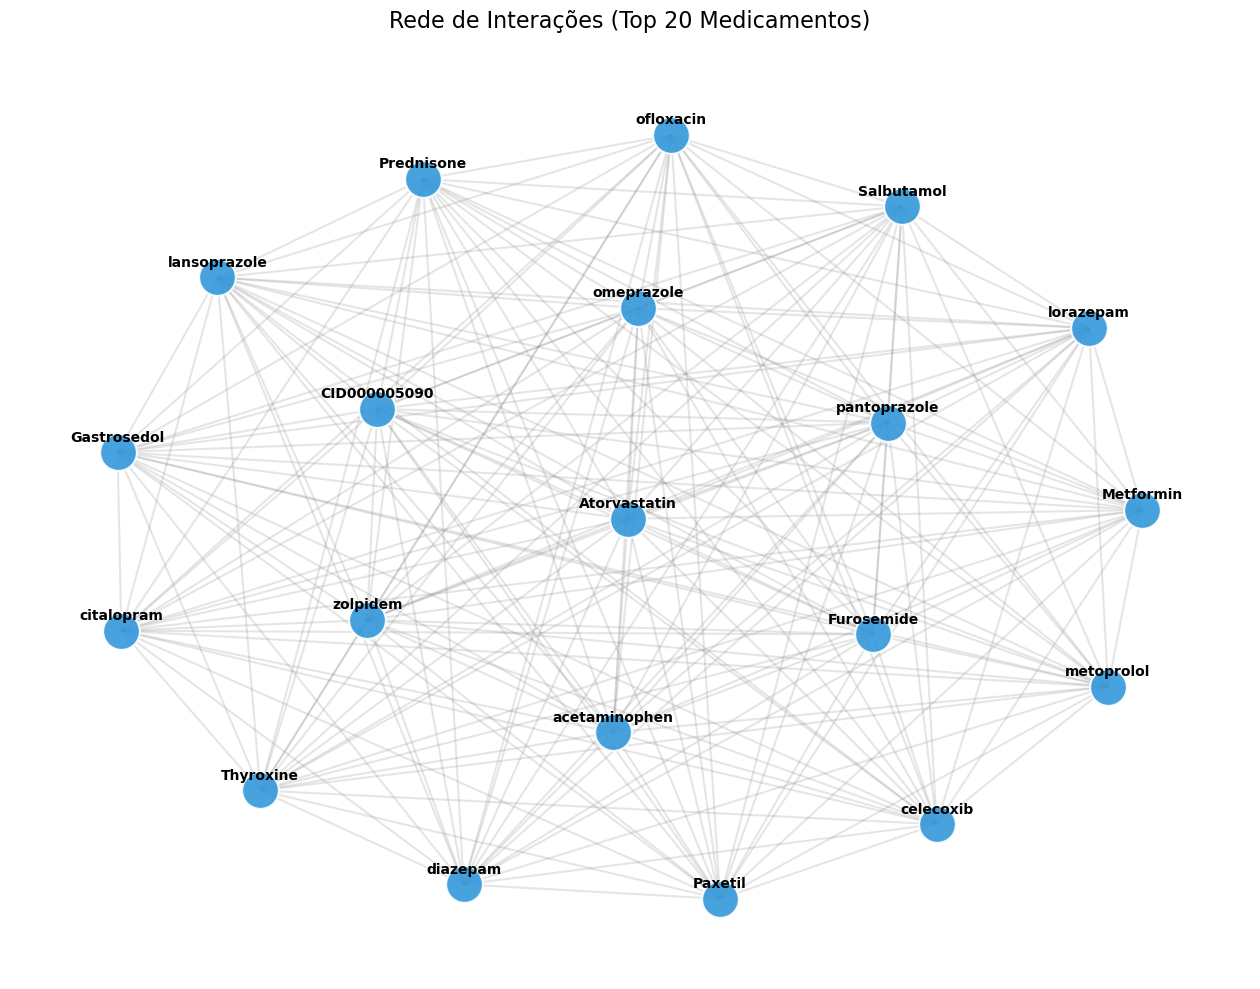

In [18]:
import requests
import time
import networkx as nx
import matplotlib.pyplot as plt

# --- 1. CONFIGURAÇÃO E FILTRAGEM ---
contagem_drogas = df_completo['# STITCH 1'].value_counts().add(df_completo['STITCH 2'].value_counts(), fill_value=0)
top_drogas_ids = contagem_drogas.nlargest(20).index 

df_visualizacao = df_completo[
    df_completo['# STITCH 1'].isin(top_drogas_ids) & 
    df_completo['STITCH 2'].isin(top_drogas_ids)
]

id_droga = {v: k for k, v in dict_drogas.items()}

# --- 2. TRADUÇÃO DE NOMES COM LIMPEZA DE "REFCHEM" ---
# Identifiquei os nomes reais dos CIDs que apareceram no teu print:
correcoes_manuais = {
    'CID000004900': 'Metformin',      # Era o RefChem:1057583
    'CID000000853': 'Thyroxine',      # Era o QR0BV3BRIA
    'CID000005203': 'Atorvastatin',   # Era o RefChem:1069861
    'CID000004635': 'Prednisone',     # Era o RefChem:1071740
    'CID000003672': 'Furosemide',     # Era o RefChem:6648
    'acetaminophen': 'Paracetamol',
    'ofloxacin': 'Ofloxacina'
}

nomes_reais = {}
print(f"A procurar nomes para {len(top_drogas_ids)} drogas no PubChem...")

for idx in top_drogas_ids:
    cid_full = id_droga[idx]
    
    # Se já estiver nas correções manuais, nem precisa de ir à API
    if cid_full in correcoes_manuais:
        nomes_reais[cid_full] = correcoes_manuais[cid_full]
        print(f"✅ {cid_full} -> {correcoes_manuais[cid_full]} (Manual)")
        continue

    cid_number = cid_full.replace('CID', '').lstrip('0')
    
    try:
        url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid_number}/synonyms/JSON"
        response = requests.get(url, timeout=5)
        sinonimos = response.json()['InformationList']['Information'][0]['Synonym']
        
        # FILTRO MELHORADO: Ignora RefChem, CAS (hífens), DTXSID e QR0BV
        nome_escolhido = cid_full
        for s in sinonimos:
            is_bad = '-' in s or 'DTXSID' in s or 'RefChem' in s or 'QR0' in s or len(s) > 20
            if not is_bad:
                nome_escolhido = s
                break
        
        nomes_reais[cid_full] = nome_escolhido
        print(f"✅ {cid_full} -> {nome_escolhido}")
    except:
        nomes_reais[cid_full] = cid_full
        print(f"❌ Erro em {cid_full}, a manter ID.")
    
    time.sleep(0.2)

# --- 3. CONSTRUÇÃO DO GRAFO ---
G = nx.Graph()
for _, linha in df_visualizacao.iterrows():
    nome_a = nomes_reais.get(id_droga[linha['# STITCH 1']])
    nome_b = nomes_reais.get(id_droga[linha['STITCH 2']])
    G.add_edge(nome_a, nome_b)

# --- 4. PLOTAGEM ---
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, k=1.5, iterations=100, seed=42)

# Ajuste das etiquetas para flutuarem sobre o nó
pos_labels = {node: (coords[0], coords[1] + 0.04) for node, coords in pos.items()}

nx.draw_networkx_nodes(G, pos, node_size=700, node_color='#3498db', edgecolors='white', linewidths=1.5, alpha=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color='gray', width=1.5)
nx.draw_networkx_labels(G, pos_labels, font_size=10, font_weight='bold')

plt.title("Rede de Interações (Top 20 Medicamentos)", fontsize=16, pad=20)
plt.axis('off')
plt.savefig('grafo_final_limpo.png', dpi=600, bbox_inches='tight')
plt.show()

In [19]:
print("\n--- ANÁLISE TOPOLÓGICA DA REDE ---")

# 1. Informações Básicas
num_nos = G.number_of_nodes()
num_arestas = G.number_of_edges()
print(f"1. Número de Medicamentos (Nós): {num_nos}")
print(f"2. Número de Interações (Arestas): {num_arestas}")

# 2. O grafo é conexo?
# Um grafo é conexo se existe um caminho entre qualquer par de nós.
is_conexo = nx.is_connected(G)
print(f"3. O grafo é conexo? {'Sim' if is_conexo else 'Não'}")

# 3. O grafo é completo? e Qual a Densidade?
# Um grafo é completo se TODOS os nós se conectam com TODOS os outros nós.
# A densidade mede a porcentagem de conexões reais vs. conexões possíveis.
densidade = nx.density(G)
is_completo = densidade == 1.0
print(f"4. O grafo é completo? {'Sim' if is_completo else 'Não'}")
print(f"5. Densidade da rede: {densidade:.4f} (ou seja, {densidade*100:.1f}% das interações possíveis estão presentes)")

# 4. Medicamentos Hubs (Centralidade de Grau)
graus = dict(G.degree())
print("\n6. Top 5 Medicamentos com mais interações (Hubs) neste subgrafo:")
top_5_hubs = sorted(graus.items(), key=lambda x: x[1], reverse=True)[:5]
for droga, grau in top_5_hubs:
    print(f"   - {droga}: {grau} interações")

# 5. Diâmetro da Rede
# O diâmetro é a maior "distância" (em número de arestas) entre dois nós no grafo.
if is_conexo:
    diametro = nx.diameter(G)
    print(f"\n7. Diâmetro da rede: {diametro} saltos máximos entre dois medicamentos.")


--- ANÁLISE TOPOLÓGICA DA REDE ---
1. Número de Medicamentos (Nós): 20
2. Número de Interações (Arestas): 190
3. O grafo é conexo? Sim
4. O grafo é completo? Sim
5. Densidade da rede: 1.0000 (ou seja, 100.0% das interações possíveis estão presentes)

6. Top 5 Medicamentos com mais interações (Hubs) neste subgrafo:
   - ofloxacin: 19 interações
   - pantoprazole: 19 interações
   - Thyroxine: 19 interações
   - Gastrosedol: 19 interações
   - Salbutamol: 19 interações

7. Diâmetro da rede: 1 saltos máximos entre dois medicamentos.


## 4 - Geração das Features

### 4.1 - Obter a representação SMILES (texto químico) para cada um dos 645 CIDs únicos via PubChem (pubchempy)

# *ATENÇÃO* | *ATENÇÃO* | *ATENÇÃO* | *ATENÇÃO* 
    só rodar essa aba na primeira vez, pois depois da tradução em smiles ele ja tem um csv com as informações, pra poupar tempo.

In [20]:
import time

def baixar_smiles(cids, tentativas=3):
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{','.join(map(str, cids))}/property/SMILES/JSON"
    for t in range(tentativas):
        try:
            r = requests.get(url, timeout=30)
            r.raise_for_status()
            props = r.json()['PropertyTable']['Properties']
            return {p['CID']: p.get('SMILES') or p.get('ConnectivitySMILES') for p in props}
        except Exception as e:
            print(f"Tentativa {t+1} falhou: {e}")
            time.sleep(2 * (t + 1))
    return {}

cids_num = [int(c[3:]) for c in drogas_unicas]
resultado = {}
for i in range(0, len(cids_num), 50):          # lotes de 50
    resultado.update(baixar_smiles(cids_num[i:i+50]))
    time.sleep(0.3)

df_id_cid_smiles = pd.DataFrame({
    'ID': range(len(drogas_unicas)),
    'CID': drogas_unicas,
    'SMILES': [resultado.get(c) for c in cids_num],
})

df_id_cid_smiles.to_csv('id_cid_smiles.csv', index=False)

print("SMILES faltando:", df_id_cid_smiles['SMILES'].isna().sum())
print("Com estereoquímica (@ ou /):", df_id_cid_smiles['SMILES'].str.contains(r'@|/|\\\\', na=False).sum())

SMILES faltando: 0
Com estereoquímica (@ ou /): 89


### 4.2 - Utilizar o RDKit para converter cada SMILES em um Morgan Fingerprint (vetor binário de 1024 bits)


In [27]:
# Para armazenar a Morgan Fingerprint usaremos uma matriz de 645 linhas e 1024 colunas. Cada coluna significa uma propriedade da mólecula (ex: coluna 42 sinaliza um anel de benzeno e 150 uma ligação dupla de oxigênio)
bits = 1024
matriz_mf = np.zeros(((quant_drogas_unicas), bits), dtype=np.float32) # transforma em float 32 pra economizar o espaço de memória
print(matriz_mf)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [28]:
from rdkit.Chem import rdFingerprintGenerator

gerador_morgan = rdFingerprintGenerator.GetMorganGenerator(
    radius=2, fpSize=1024, includeChirality=True
)

# Função de transformação SMILES -> Morgan Fingerprint
def smiles_para_mf(smiles):

    if smiles is None:
        return np.zeros((1024,), dtype=np.float32)

    # Transformando o smiles em objeto químico
    mol = Chem.MolFromSmiles(smiles)

    if mol:
        return gerador_morgan.GetFingerprintAsNumPy(mol).astype('float32') 

    # Caso o SMILES seja inválido
    return np.zeros((1024,), dtype=np.float32)

In [29]:
matriz_antiga = matriz_mf.copy()

In [32]:
# Loop que percorre o df_id_cid_smiles pra gerar cada fingerprint

for index, linha in df_id_cid_smiles.iterrows():
    id_atual = int(linha['ID'])
    texto_smiles = linha['SMILES']

    mf = smiles_para_mf(texto_smiles)

    matriz_mf[id_atual] = mf

print("Matriz de Morgan Fingerprint criada!")
    

Matriz de Morgan Fingerprint criada!


### 4.3 - Construir a Matriz de Nós X: um tensor de tamanho [645, 1024] onde a linha i contém o fingerprint da droga mapeada com o ID i.

In [33]:
tensor_x = torch.tensor(matriz_mf, dtype=torch.float32)

## 5 - Criando o Objeto Data

    O objeto data contém todos os atributos (componentes) organizados

### 5.1 - Criar o data.x


In [34]:
from torch_geometric.data import Data

x = torch.from_numpy(matriz_mf).to(torch.float32)

### 5.2 - Criar edge_index

In [49]:
# Pegando coluna de IDs
origem = torch.tensor(df_completo['# STITCH 1'].values, dtype=torch.long)
destino = torch.tensor(df_completo['STITCH 2'].values, dtype=torch.long)

# Empilhamos as duas listas para formar o par
edge_index = torch.stack([origem, destino], dim=0)

### 5.3 - Criar edge_type

In [50]:
# Pegamos a coluna onde você mapeou os nomes dos efeitos para IDs numéricos (0 a 1316)
edge_type = torch.tensor(df_completo['Polypharmacy Side Effect'].values, dtype=torch.long)

In [51]:
data = Data(x=x, edge_index=edge_index)
data.edge_type = edge_type

print("CARACTERISTICAS DO GRAFO:")
print(f"Nós (Drogas): {data.num_nodes}")
print(f"Arestas (Conexões): {data.num_edges}")
print(f"Características por Nó: {data.num_node_features}")

CARACTERISTICAS DO GRAFO:
Nós (Drogas): 645
Arestas (Conexões): 4576287
Características por Nó: 1024


## 6 - Separar as conexões para Treino, Validação e Teste

In [52]:
from torch_geometric.transforms import RandomLinkSplit

In [53]:
torch.manual_seed(42)
num_edges = edge_index.size(1)
perm = torch.randperm(num_edges)

n_val   = int(0.1 * num_edges)
n_test  = int(0.1 * num_edges)
n_train = num_edges - n_val - n_test

idx_train = perm[:n_train]
idx_val   = perm[n_train : n_train + n_val]
idx_test  = perm[n_train + n_val :]

# Arestas de treino em mão dupla (só para passagem de mensagens)
ei_tr = edge_index[:, idx_train]
et_tr = edge_type[idx_train]
mp_edge_index = torch.cat([ei_tr, ei_tr.flip(0)], dim=1)
mp_edge_type  = torch.cat([et_tr, et_tr], dim=0)

train_data = Data(x=x)
train_data.edge_index = mp_edge_index
train_data.edge_type  = mp_edge_type
train_data.edge_label_index = edge_index[:, idx_train]
train_data.edge_label_type  = edge_type[idx_train]

val_data = Data(x=x)
val_data.edge_index = mp_edge_index
val_data.edge_type  = mp_edge_type
val_data.edge_label_index = edge_index[:, idx_val]
val_data.edge_label_type  = edge_type[idx_val]

test_data = Data(x=x)
test_data.edge_index = mp_edge_index
test_data.edge_type  = mp_edge_type
test_data.edge_label_index = edge_index[:, idx_test]
test_data.edge_label_type  = edge_type[idx_test]

print(train_data.edge_index.shape)        # esperado: [2, ~7,4 milhões]
print(train_data.edge_label_index.shape)  # esperado: [2, ~3,7 milhões]

torch.Size([2, 7322062])
torch.Size([2, 3661031])


In [54]:
# Confirmações

tipos_train = set(edge_type[idx_train].unique().tolist())
tipos_val   = set(edge_type[idx_val].unique().tolist())
tipos_test  = set(edge_type[idx_test].unique().tolist())

print("Tipos em train:", len(tipos_train), "/ 1317")
print("Tipos em val:  ", len(tipos_val))
print("Tipos em test: ", len(tipos_test))
print("Tipos de val/test que NÃO aparecem no treino:",
      len((tipos_val | tipos_test) - tipos_train))

contagem = torch.bincount(edge_type, minlength=1317)
print("Menor efeito:", contagem.min().item(), "arestas | Maior:", contagem.max().item())

Tipos em train: 963 / 1317
Tipos em val:   963
Tipos em test:  963
Tipos de val/test que NÃO aparecem no treino: 0
Menor efeito: 0 arestas | Maior: 28568


In [47]:
for n in [10, 50, 100, 500, 1000, 1500]:
    mantidos = (contagem >= n).sum().item()
    arestas  = contagem[contagem >= n].sum().item()
    print(f"≥{n:>3} arestas: {mantidos} efeitos, {arestas:,} arestas ({arestas/num_edges:.1%})")

≥ 10 arestas: 1300 efeitos, 4,649,366 arestas (100.0%)
≥ 50 arestas: 1255 efeitos, 4,648,156 arestas (100.0%)
≥100 arestas: 1211 efeitos, 4,644,799 arestas (99.9%)
≥500 arestas: 963 efeitos, 4,576,287 arestas (98.4%)
≥1000 arestas: 782 efeitos, 4,443,375 arestas (95.6%)
≥1500 arestas: 680 efeitos, 4,318,822 arestas (92.9%)


## 7 - Separar para levar o importante para o notebook da GNN

In [58]:
objetos_gnn = {
    'train_data': train_data,
    'val_data': val_data,
    'test_data': test_data,
    'n_nodes': data.num_nodes,
    'n_relations': n_relacoes,
    'nomes_efeitos': nomes_novo,
    'in_channels': 1024
}

torch.save(objetos_gnn, 'dados_prontos.pt')

print("Tudo salvo! Agora você pode abrir o Notebook da GNN.")

Tudo salvo! Agora você pode abrir o Notebook da GNN.


# Imagens


In [34]:
import requests
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
import numpy as np
from PIL import Image

cid_exemplo = '1983'
nome_droga = "Paracetamol"

def get_smiles(cid):
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/property/SMILES/JSON"
    r = requests.get(url).json()
    return r['PropertyTable']['Properties'][0]['SMILES']

smiles = get_smiles(cid_exemplo)
mol = Chem.MolFromSmiles(smiles)
gen = AllChem.GetMorganGenerator(radius=2, fpSize=1024)
fp_array = np.array(gen.GetCountFingerprintAsNumPy(mol) > 0)

# --- 1. CID ---
fig, ax = plt.subplots(figsize=(3, 2))
ax.text(0.5, 0.5, f"CID\n{cid_exemplo}", fontsize=20, fontweight='bold',
        ha='center', va='center',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.6'))
ax.set_title(f"SUBSTÂNCIA:\n{nome_droga}", fontsize=11, fontweight='bold', pad=6)
ax.axis('off')
plt.savefig('bloco_cid.png', dpi=600, bbox_inches='tight', transparent=True)
plt.close()

# --- 2. Molécula ---
fig, ax = plt.subplots(figsize=(4, 3))
img = Draw.MolToImage(mol, size=(800, 800))
ax.imshow(img)
ax.set_title(f"SMILES:\n{smiles}", fontsize=11, fontweight='bold', pad=6)
ax.axis('off')
plt.savefig('bloco_smiles.png', dpi=600, bbox_inches='tight', transparent=True)
plt.close()

# --- 3. Morgan Fingerprint ---
fig, ax = plt.subplots(figsize=(10, 1.2))
ax.imshow(fp_array[:1024].reshape(1, -1), cmap='Greys', aspect='auto',
          interpolation='nearest')
ax.set_yticks([])
ax.set_xticks(np.arange(0, 1025, 200))
ax.set_title("MORGAN FINGERPRINT\n(Vetor de Atributos)", fontsize=11, fontweight='bold', pad=6)
ax.set_xlabel("Vetor Binário (1024 bits)", fontsize=9)
plt.savefig('bloco_fingerprint.png', dpi=600, bbox_inches='tight', transparent=True)
plt.close()

print("Salvo: bloco_cid.png, bloco_smiles.png, bloco_fingerprint.png")

Salvo: bloco_cid.png, bloco_smiles.png, bloco_fingerprint.png


In [36]:
import matplotlib.pyplot as plt
import numpy as np



# --- 2. Barcode vertical ---
fig, ax = plt.subplots(figsize=(0.4, 3))
ax.imshow(fp_array[:1024].reshape(1024, 1), cmap='Greys', aspect='auto', interpolation='nearest')
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("MORGAN\nFINGERPRINT\n(Vetor de\nAtributos)", fontsize=9, fontweight='bold', pad=6)
plt.savefig('vetor_barcode_vertical.png', dpi=600, bbox_inches='tight', transparent=True)
plt.close()

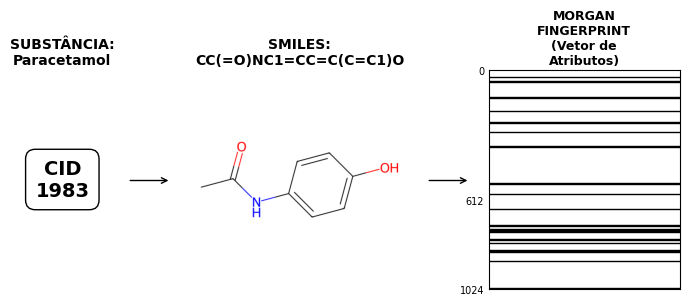

In [37]:
import requests
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
import numpy as np

cid_exemplo = '1983'
nome_droga = "Paracetamol"

def get_smiles(cid):
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/property/SMILES/JSON"
    r = requests.get(url).json()
    return r['PropertyTable']['Properties'][0]['SMILES']

smiles = get_smiles(cid_exemplo)
mol = Chem.MolFromSmiles(smiles)
gen = AllChem.GetMorganGenerator(radius=2, fpSize=1024)
fp_array = np.array(gen.GetCountFingerprintAsNumPy(mol) > 0)

fig, ax = plt.subplots(1, 3, figsize=(7, 3),
                       gridspec_kw={'width_ratios': [0.4, 1.5, 0.8]})

# A. CID
ax[0].text(0.5, 0.5, f"CID\n{cid_exemplo}", fontsize=14, fontweight='bold',
           ha='center', va='center',
           bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))
ax[0].set_title(f"SUBSTÂNCIA:\n{nome_droga}", fontsize=10, fontweight='bold', pad=4)
ax[0].axis('off')

# B. Molécula
img = Draw.MolToImage(mol, size=(500, 500))
ax[1].imshow(img)
ax[1].set_title(f"SMILES:\n{smiles}", fontsize=10, fontweight='bold', pad=4)
ax[1].axis('off')

# C. Barcode vertical
ax[2].set_xlim(0, 1)
ax[2].set_ylim(1024, 0)  # invertido pra 0 ficar em cima
ax[2].set_xticks([])
ax[2].set_yticks([0, 612, 1024])
ax[2].set_yticklabels(['0', '612', '1024'], fontsize=7)
ax[2].yaxis.set_tick_params(length=0)

thickness = 2  # espessura em unidades de bit
for i, bit in enumerate(fp_array[:1024]):
    if bit:
        ax[2].axhspan(i, i + thickness, xmin=0, xmax=1, color='black')

ax[2].set_title("MORGAN\nFINGERPRINT\n(Vetor de\nAtributos)", fontsize=9, fontweight='bold', pad=4)

plt.subplots_adjust(wspace=0.05, left=0.02, right=0.97, top=0.78, bottom=0.05)

# Setas calculadas automaticamente
fig.canvas.draw()

for ax_l, ax_r in [(ax[0], ax[1]), (ax[1], ax[2])]:
    pos_l = ax_l.get_position()
    pos_r = ax_r.get_position()
    x_start = pos_l.x1
    x_end   = pos_r.x0
    y = (pos_l.y0 + pos_l.y1) / 2
    ax[0].annotate('', xy=(x_end, y), xytext=(x_start, y),
                   xycoords='figure fraction', textcoords='figure fraction',
                   arrowprops=dict(arrowstyle='->', lw=1, color='black', shrinkA=15, shrinkB=15))

plt.savefig('fluxo_entrada_final.png', dpi=600, bbox_inches='tight')
plt.show()

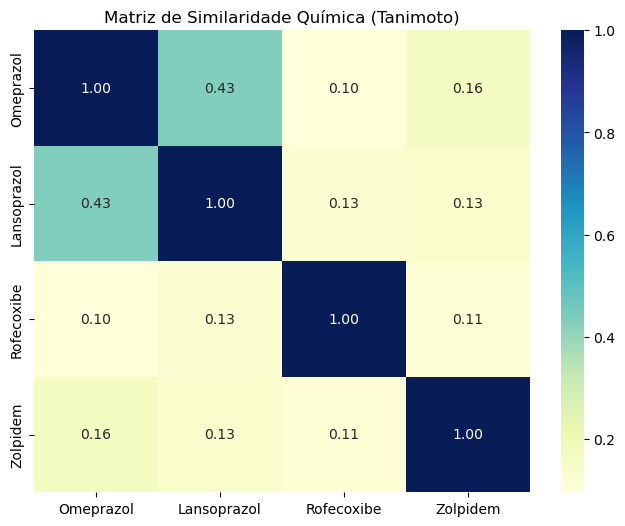

In [38]:
import seaborn as sns
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
import matplotlib.pyplot as plt

# 1. Lista dos CIDs (Omeprazol, Lansoprazol, Rofecoxibe, Zolpidem)
# Usando os nomes para as labels do gráfico
medicamentos = {
    "Omeprazol": "CC1=CN=C(C(=C1OC)C)CS(=O)C2=NC3=C(N2)C=C(C=C3)OC",
    "Lansoprazol": "CC1=C(C=CN=C1CS(=O)C2=NC3=CC=CC=C3N2)OCC(F)(F)F",
    "Rofecoxibe": "CS(=O)(=O)C1=CC=C(C=C1)C2=C(C(=O)OC2)C3=CC=CC=C3",
    "Zolpidem": "CN(C)C(=O)CN1C2=C(C=C(C=C2)C)N=C1C3=CC=C(C=C3)C"
}

# 2. Gerar as moléculas e os Fingerprints (1024 bits)
mols = [Chem.MolFromSmiles(s) for s in medicamentos.values()]

# Criar o gerador (substitui o GetMorganFingerprintAsBitVect)
gen = AllChem.GetMorganGenerator(radius=2, fpSize=1024)

# Gerar os fingerprints através do gerador
fps = [gen.GetFingerprint(m) for m in mols]

# 3. Calcular a Matriz de Similaridade de Tanimoto
n = len(fps)
matrix = []
for i in range(n):
    row = []
    for j in range(n):
        sim = DataStructs.TanimotoSimilarity(fps[i], fps[j])
        row.append(sim)
    matrix.append(row)

# 4. Plotar o Heatmap
df_sim = pd.DataFrame(matrix, index=medicamentos.keys(), columns=medicamentos.keys())

plt.figure(figsize=(8, 6))
sns.heatmap(df_sim, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Matriz de Similaridade Química (Tanimoto)")
plt.savefig('heatmap_tcc_final.png', dpi=600, bbox_inches='tight')
plt.show()

# Referências:

- https://networkx.org/documentation/stable/
- https://docs.pubchempy.org/en/latest/
- https://www.rdkit.org/docs/GettingStartedInPython.html
- https://docs.pytorch.org/docs/stable/index.html
- https://www.python.org/
- https://pandas.pydata.org/